# Distancias y agrupamiento genético - construcción de árboles filogenéticos

Bienvenidos bioniños al último taller del corte. En esta ocasión estaremos trabajando los conceptos de distancia y agrupamiento genético para construir un ejercicio de filogenia con 10 especies de primates (5 del viejo mundo y 5 del nuevo mundo). Trabajaremos los conceptos de alineamiento, múltiples modelos de distancia genética con **funciones independientes** (**Jukes-Cantor (JC69)**, **Kimura 2-Parámetros (K2P)** y **Tamura-Nei (TN93)**), agrupamiento exclusivamente por **Neighbor-Joining (NJ)** y finalmente la visualización y comparación de nuestros árboles filogenéticos usando Biopython y Matplotlib.

En esta carpeta cuentan con el archivo `primates_COI_aligned.fasta`, el cual contiene el alineamiento múltiple de las secuencias de la región COX1 para cada uno de estos primates. Aclaremos dos conceptos relevantes.

# Primates del viejo y nuevo mundo

Los monos del Viejo Mundo son aquellos que habitan África y Asia. Se clasifican como tales porque esta región era conocida por los europeos antes de su llegada a América, a la que denominaban Nuevo Mundo. Por lo tanto los monos del Nuevo mundo son aquellos que habitan América. La diferencia entre estas dos categorías de monos es principalmente geográfica, pero existen rasgos evolutivos y biológicos que también los distinguen. Su ancestro común divergió hace millones de años, llegando a América desde África. Posteriormente, las especies comenzaron a evolucionar en este nuevo entorno, lo que dio lugar a diferentes adaptaciones. Por esto a los monos del viejo mundo se les denomina Catarrinos, "nariz hacia abajo", debido que sus fosas nasales se encuentran predominantemente juntas. Los monos del nuevo mundo son Platirrinos, "nariz plana"; tienen fosas nasales separadas y dirigidas hacia los lados. Muchos poseen colas prensiles (que actúan como un quinto miembro).

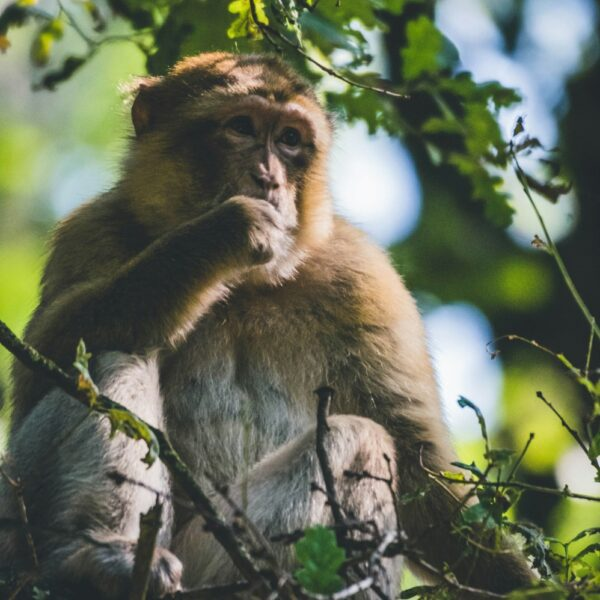

Mono del viejo mundo: macaco de Berbería

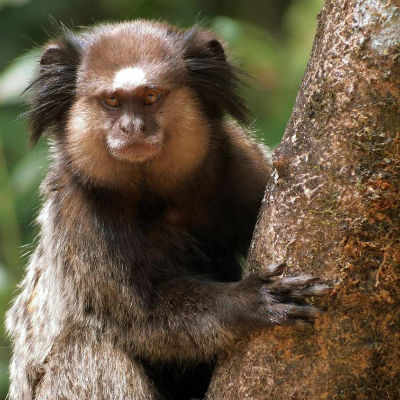

Mono del nuevo mundo: tití de penacho negro

# Gen COI 

El gen COI codifica para una enzima ampliamente estudiada: la subunidad I de la enzima Citocromo c Oxidasa. Esta es la enzima terminal de la cadena de transporte de electrones, COI es un gen mitocondrial denominado como "código de barras", pues se utiliza universalmente para identificar especies animales por razones principales como:

    1. Al ser un gen mitocondrial, tiene muchas copias dentro de un organismo
    
    2. Carece de intrones, lo cual facilita procesos de secuenciación
    
    3. Tiene una tasa de mutación lo suficientemente alta para diferenciar especies, pero lo suficientemente conservada para alinear las secuencias.

# 1. Lectura del alineamiento y etiquetado de organismos (Viejo / Nuevo Mundo)

Cargamos el alineamiento `primates_COI_aligned.fasta` y actualizamos los nombres de las especies para indicar explícitamente su procedencia evolutiva/geográfica: **(Nuevo Mundo)** o **(Viejo Mundo)**.

In [1]:
from Bio import AlignIO

# 1. Cargar el alineamiento desde el archivo FASTA
alineamiento = AlignIO.read("primates_COI_aligned.fasta", "fasta")

# 2. Diccionario con la procedencia biogeográfica de cada primate
origen_primate = {
    "Alouatta_palliata": "Nuevo Mundo",
    "Ateles_geoffroyi": "Nuevo Mundo",
    "Callithrix_jacchus": "Nuevo Mundo",
    "Cebus_imitator": "Nuevo Mundo",
    "Saimiri_sciureus": "Nuevo Mundo",
    "Chlorocebus_sabaeus": "Viejo Mundo",
    "Colobus_guereza": "Viejo Mundo",
    "Macaca_mulatta_vestita": "Viejo Mundo",
    "Nasalis_larvatus": "Viejo Mundo",
    "Papio_anubis": "Viejo Mundo"
}

# 3. Asignar etiquetas claras a cada registro
for record in alineamiento:
    nombre_base = record.id.split("_[")[0].split(" (")[0]
    mundo = origen_primate.get(nombre_base, "Desconocido")
    record.id = f"{nombre_base} ({mundo})"
    record.description = ""

# 4. Mostrar resumen
print(f"Secuencias cargadas: {len(alineamiento)}")
print(f"Longitud del alineamiento: {alineamiento.get_alignment_length()} posiciones\n")
print("Especies listas para análisis:")
for i, rec in enumerate(alineamiento, 1):
    print(f"  {i:2d}. {rec.id}")


Secuencias cargadas: 10
Longitud del alineamiento: 1572 posiciones

Especies listas para análisis:
   1. Callithrix_jacchus (Nuevo Mundo)
   2. Ateles_geoffroyi (Nuevo Mundo)
   3. Macaca_mulatta_vestita (Viejo Mundo)
   4. Nasalis_larvatus (Viejo Mundo)
   5. Colobus_guereza (Viejo Mundo)
   6. Papio_anubis (Viejo Mundo)
   7. Saimiri_sciureus (Nuevo Mundo)
   8. Alouatta_palliata (Nuevo Mundo)
   9. Cebus_imitator (Nuevo Mundo)
  10. Chlorocebus_sabaeus (Viejo Mundo)


# 2. Cálculo de distancias genéticas con funciones independientes

A continuación implementamos **una función independiente y muy comentada para cada modelo de distancia**:

### A. Jukes-Cantor (JC69)
Fórmula:
$$d_{JC} = -\frac{3}{4} \ln\left(1 - \frac{4}{3} p\right)$$
donde $p$ es la proporción de sitios diferentes.

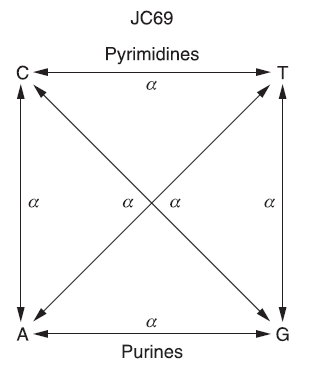
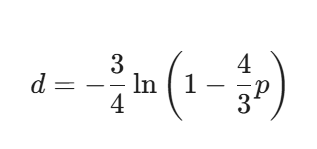

### B. Kimura 2-Parámetros (K2P / K80)
Fórmula:
$$d_{K2P} = -\frac{1}{2} \ln(1 - 2P - Q) - \frac{1}{4} \ln(1 - 2Q)$$
donde $P$ es la proporción de transiciones y $Q$ es la proporción de transversiones.

### C. Tamura-Nei (TN93)
Fórmula:
$$k_1 = \frac{2 g_A g_G}{g_R}, \quad k_2 = \frac{2 g_C g_T}{g_Y}, \quad k_3 = 2 g_R g_Y \quad (g_R = g_A + g_G, \; g_Y = g_C + g_T)$$
$$d_{TN93} = -k_1 \ln\left(1 - \frac{P_1}{k_1} - \frac{g_R Q}{k_3}\right) - k_2 \ln\left(1 - \frac{P_2}{k_2} - \frac{g_Y Q}{k_3}\right) - \left(k_3 - \frac{g_R k_2 + g_Y k_1}{g_R + g_Y}\right) \ln\left(1 - \frac{Q}{k_3}\right)$$

In [2]:
import math
import numpy as np
import pandas as pd
from Bio.Phylo.TreeConstruction import _DistanceMatrix

# ==============================================================================
# FUNCIÓN 1: DISTANCIA DE JUKES-CANTOR (JC69)
# ==============================================================================
def calcular_matriz_jc69(alineamiento):
    """
    Calcula la matriz de distancias usando el modelo Jukes-Cantor (JC69).
    Fórmula: d = -3/4 * ln(1 - 4/3 * p)
    """
    nombres = [rec.id for rec in alineamiento]
    n = len(alineamiento)
    matriz = []
    validas = {"A", "C", "G", "T"}
    
    for i in range(n):
        fila = []
        seq1 = str(alineamiento[i].seq).upper()
        
        for j in range(i + 1):
            if i == j:
                fila.append(0.0)
                continue
                
            seq2 = str(alineamiento[j].seq).upper()
            
            # Contar posiciones válidas y diferencias totales
            validos = 0
            diferencias = 0
            
            for b1, b2 in zip(seq1, seq2):
                if b1 in validas and b2 in validas:
                    validos += 1
                    if b1 != b2:
                        diferencias += 1
            
            # Proporción de sitios diferentes (p)
            p = diferencias / validos
            
            # Fórmula Jukes-Cantor
            d_jc = -0.75 * math.log(1.0 - (4.0 / 3.0) * p)
            fila.append(d_jc)
            
        matriz.append(fila)
        
    return _DistanceMatrix(nombres, matriz)


# ==============================================================================
# FUNCIÓN 2: DISTANCIA DE KIMURA 2-PARÁMETROS (K2P)
# ==============================================================================
def calcular_matriz_k2p(alineamiento):
    """
    Calcula la matriz de distancias usando el modelo Kimura 2-Parámetros (K2P).
    Fórmula: d = -1/2 * ln(1 - 2P - Q) - 1/4 * ln(1 - 2Q)
    """
    nombres = [rec.id for rec in alineamiento]
    n = len(alineamiento)
    matriz = []
    
    purinas = {"A", "G"}
    pirimidinas = {"C", "T"}
    validas = {"A", "C", "G", "T"}
    
    for i in range(n):
        fila = []
        seq1 = str(alineamiento[i].seq).upper()
        
        for j in range(i + 1):
            if i == j:
                fila.append(0.0)
                continue
                
            seq2 = str(alineamiento[j].seq).upper()
            
            validos = 0
            transiciones = 0    # A <-> G  o  C <-> T
            transversiones = 0  # Purina <-> Pirimidina
            
            for b1, b2 in zip(seq1, seq2):
                if b1 in validas and b2 in validas:
                    validos += 1
                    if b1 != b2:
                        # Transición (mismo grupo químico)
                        if (b1 in purinas and b2 in purinas) or (b1 in pirimidinas and b2 in pirimidinas):
                            transiciones += 1
                        else: # Transversión (cambio de grupo)
                            transversiones += 1
            
            # Proporciones de transiciones (P) y transversiones (Q)
            P = transiciones / validos
            Q = transversiones / validos
            
            # Fórmula Kimura 2-Parámetros
            d_k2p = -0.5 * math.log(1.0 - 2.0 * P - Q) - 0.25 * math.log(1.0 - 2.0 * Q)
            fila.append(d_k2p)
            
        matriz.append(fila)
        
    return _DistanceMatrix(nombres, matriz)


# ==============================================================================
# FUNCIÓN 3: DISTANCIA DE TAMURA-NEI (TN93)
# ==============================================================================
def calcular_matriz_tn93(alineamiento):
    """
    Calcula la matriz de distancias usando el modelo Tamura-Nei (TN93).
    Distingue transiciones purinas (A<->G), pirimidinas (C<->T), transversiones
    y frecuencias empíricas de bases.
    """
    nombres = [rec.id for rec in alineamiento]
    n = len(alineamiento)
    matriz = []
    
    purinas = {"A", "G"}
    pirimidinas = {"C", "T"}
    validas = {"A", "C", "G", "T"}
    
    for i in range(n):
        fila = []
        seq1 = str(alineamiento[i].seq).upper()
        
        for j in range(i + 1):
            if i == j:
                fila.append(0.0)
                continue
                
            seq2 = str(alineamiento[j].seq).upper()
            
            validos = 0
            ts_purinas = 0      # A <-> G
            ts_pirimidinas = 0  # C <-> T
            transversiones = 0  # Purina <-> Pirimidina
            conteos = {"A": 0, "C": 0, "G": 0, "T": 0}
            
            for b1, b2 in zip(seq1, seq2):
                if b1 in validas and b2 in validas:
                    validos += 1
                    conteos[b1] += 1
                    conteos[b2] += 1
                    
                    if b1 != b2:
                        if b1 in purinas and b2 in purinas:
                            ts_purinas += 1
                        elif b1 in pirimidinas and b2 in pirimidinas:
                            ts_pirimidinas += 1
                        else:
                            transversiones += 1
            
            # Proporciones
            P1 = ts_purinas / validos
            P2 = ts_pirimidinas / validos
            Q = transversiones / validos
            
            # Frecuencias de bases empíricas
            total_bases = sum(conteos.values())
            gA = conteos["A"] / total_bases
            gC = conteos["C"] / total_bases
            gG = conteos["G"] / total_bases
            gT = conteos["T"] / total_bases
            gR = gA + gG  # Purinas totales
            gY = gC + gT  # Pirimidinas totales
            
            # Coeficientes Tamura-Nei
            k1 = (2.0 * gA * gG) / gR
            k2 = (2.0 * gC * gT) / gY
            k3 = 2.0 * gR * gY
            
            term1 = 1.0 - (P1 / k1) - (gR * Q / k3)
            term2 = 1.0 - (P2 / k2) - (gY * Q / k3)
            term3 = 1.0 - (Q / k3)
            coef3 = k3 - (gR * k2 + gY * k1) / (gR + gY)
            
            # Fórmula Tamura-Nei (1993)
            d_tn93 = -k1 * math.log(term1) - k2 * math.log(term2) - coef3 * math.log(term3)
            fila.append(d_tn93)
            
        matriz.append(fila)
        
    return _DistanceMatrix(nombres, matriz)


# ------------------------------------------------------------------------------
# Ejecutar las 3 funciones independientes y mostrar las matrices
# ------------------------------------------------------------------------------
matriz_jc69 = calcular_matriz_jc69(alineamiento)
matriz_k2p  = calcular_matriz_k2p(alineamiento)
matriz_tn93 = calcular_matriz_tn93(alineamiento)

def mostrar_tabla(matriz_dist, titulo):
    n = len(matriz_dist.names)
    tabla = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            tabla[i, j] = matriz_dist[i, j]
    print(f"=== {titulo} ===")
    df = pd.DataFrame(tabla, index=matriz_dist.names, columns=matriz_dist.names)
    display(df.round(4))

mostrar_tabla(matriz_jc69, "Matriz de Distancias: Jukes-Cantor (JC69)")
mostrar_tabla(matriz_k2p,  "Matriz de Distancias: Kimura 2-Parámetros (K2P)")
mostrar_tabla(matriz_tn93, "Matriz de Distancias: Tamura-Nei (TN93)")


=== Matriz de Distancias: Jukes-Cantor (JC69) ===


,Callithrix_jacchus (Nuevo Mundo),Ateles_geoffroyi (Nuevo Mundo),Macaca_mulatta_vestita (Viejo Mundo),Nasalis_larvatus (Viejo Mundo),Colobus_guereza (Viejo Mundo),Papio_anubis (Viejo Mundo),Saimiri_sciureus (Nuevo Mundo),Alouatta_palliata (Nuevo Mundo),Cebus_imitator (Nuevo Mundo),Chlorocebus_sabaeus (Viejo Mundo)
Callithrix_jacchus (Nuevo Mundo),0.0000,0.1821,0.2451,0.2524,0.2597,0.2680,0.1989,0.1698,0.1732,0.2462
Ateles_geoffroyi (Nuevo Mundo),0.1821,0.0000,0.2488,0.2460,0.2605,0.2865,0.1818,0.1332,0.1646,0.2562
Macaca_mulatta_vestita (Viejo Mundo),0.2451,0.2488,0.0000,0.2152,0.2092,0.1711,0.2593,0.2354,0.2436,0.1675
Nasalis_larvatus (Viejo Mundo),0.2524,0.2460,0.2152,0.0000,0.1588,0.2083,0.2583,0.2469,0.2516,0.2110
Colobus_guereza (Viejo Mundo),0.2597,0.2605,0.2092,0.1588,0.0000,0.2335,0.2666,0.2559,0.2543,0.2355
Papio_anubis (Viejo Mundo),0.2680,0.2865,0.1711,0.2083,0.2335,0.0000,0.2854,0.2706,0.2571,0.1756
Saimiri_sciureus (Nuevo Mundo),0.1989,0.1818,0.2593,0.2583,0.2666,0.2854,0.0000,0.1818,0.1979,0.2756
Alouatta_palliata (Nuevo Mundo),0.1698,0.1332,0.2354,0.2469,0.2559,0.2706,0.1818,0.0000,0.1727,0.2444
Cebus_imitator (Nuevo Mundo),0.1732,0.1646,0.2436,0.2516,0.2543,0.2571,0.1979,0.1727,0.0000,0.2437
Chlorocebus_sabaeus (Viejo Mundo),0.2462,0.2562,0.1675,0.2110,0.2355,0.1756,0.2756,0.2444,0.2437,0.0000


=== Matriz de Distancias: Kimura 2-Parámetros (K2P) ===


,Callithrix_jacchus (Nuevo Mundo),Ateles_geoffroyi (Nuevo Mundo),Macaca_mulatta_vestita (Viejo Mundo),Nasalis_larvatus (Viejo Mundo),Colobus_guereza (Viejo Mundo),Papio_anubis (Viejo Mundo),Saimiri_sciureus (Nuevo Mundo),Alouatta_palliata (Nuevo Mundo),Cebus_imitator (Nuevo Mundo),Chlorocebus_sabaeus (Viejo Mundo)
Callithrix_jacchus (Nuevo Mundo),0.0000,0.1871,0.2498,0.2565,0.2651,0.2744,0.2032,0.1740,0.1780,0.2507
Ateles_geoffroyi (Nuevo Mundo),0.1871,0.0000,0.2533,0.2504,0.2656,0.2953,0.1864,0.1367,0.1695,0.2617
Macaca_mulatta_vestita (Viejo Mundo),0.2498,0.2533,0.0000,0.2245,0.2163,0.1801,0.2644,0.2391,0.2486,0.1755
Nasalis_larvatus (Viejo Mundo),0.2565,0.2504,0.2245,0.0000,0.1641,0.2168,0.2624,0.2510,0.2567,0.2199
Colobus_guereza (Viejo Mundo),0.2651,0.2656,0.2163,0.1641,0.0000,0.2436,0.2716,0.2614,0.2602,0.2454
Papio_anubis (Viejo Mundo),0.2744,0.2953,0.1801,0.2168,0.2436,0.0000,0.2927,0.2774,0.2636,0.1847
Saimiri_sciureus (Nuevo Mundo),0.2032,0.1864,0.2644,0.2624,0.2716,0.2927,0.0000,0.1867,0.2046,0.2816
Alouatta_palliata (Nuevo Mundo),0.1740,0.1367,0.2391,0.2510,0.2614,0.2774,0.1867,0.0000,0.1784,0.2489
Cebus_imitator (Nuevo Mundo),0.1780,0.1695,0.2486,0.2567,0.2602,0.2636,0.2046,0.1784,0.0000,0.2488
Chlorocebus_sabaeus (Viejo Mundo),0.2507,0.2617,0.1755,0.2199,0.2454,0.1847,0.2816,0.2489,0.2488,0.0000


=== Matriz de Distancias: Tamura-Nei (TN93) ===


,Callithrix_jacchus (Nuevo Mundo),Ateles_geoffroyi (Nuevo Mundo),Macaca_mulatta_vestita (Viejo Mundo),Nasalis_larvatus (Viejo Mundo),Colobus_guereza (Viejo Mundo),Papio_anubis (Viejo Mundo),Saimiri_sciureus (Nuevo Mundo),Alouatta_palliata (Nuevo Mundo),Cebus_imitator (Nuevo Mundo),Chlorocebus_sabaeus (Viejo Mundo)
Callithrix_jacchus (Nuevo Mundo),0.0000,0.1936,0.2591,0.2640,0.2728,0.2831,0.2096,0.1795,0.1830,0.2582
Ateles_geoffroyi (Nuevo Mundo),0.1936,0.0000,0.2600,0.2584,0.2741,0.3078,0.1937,0.1400,0.1753,0.2698
Macaca_mulatta_vestita (Viejo Mundo),0.2591,0.2600,0.0000,0.2319,0.2235,0.1861,0.2709,0.2454,0.2565,0.1785
Nasalis_larvatus (Viejo Mundo),0.2640,0.2584,0.2319,0.0000,0.1676,0.2241,0.2705,0.2582,0.2646,0.2254
Colobus_guereza (Viejo Mundo),0.2728,0.2741,0.2235,0.1676,0.0000,0.2520,0.2796,0.2693,0.2677,0.2523
Papio_anubis (Viejo Mundo),0.2831,0.3078,0.1861,0.2241,0.2520,0.0000,0.3032,0.2864,0.2727,0.1873
Saimiri_sciureus (Nuevo Mundo),0.2096,0.1937,0.2709,0.2705,0.2796,0.3032,0.0000,0.1919,0.2108,0.2907
Alouatta_palliata (Nuevo Mundo),0.1795,0.1400,0.2454,0.2582,0.2693,0.2864,0.1919,0.0000,0.1840,0.2554
Cebus_imitator (Nuevo Mundo),0.1830,0.1753,0.2565,0.2646,0.2677,0.2727,0.2108,0.1840,0.0000,0.2561
Chlorocebus_sabaeus (Viejo Mundo),0.2582,0.2698,0.1785,0.2254,0.2523,0.1873,0.2907,0.2554,0.2561,0.0000


# 3. Agrupamiento exclusivamente por Neighbor-Joining (NJ)

A partir de las tres matrices de distancia calculadas (JC69, K2P, TN93), construimos los árboles filogenéticos utilizando **exclusivamente el método de Neighbor-Joining (NJ)**:

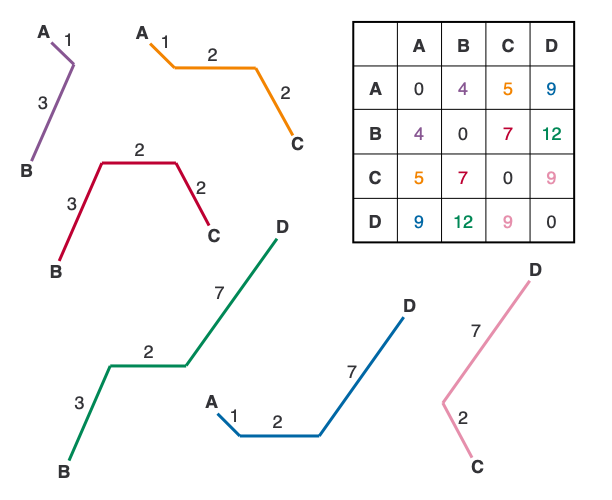

In [3]:
from Bio.Phylo.TreeConstruction import DistanceTreeConstructor
from Bio import Phylo

# 1. Crear el constructor de árboles filogenéticos
constructor = DistanceTreeConstructor()

# 2. Construir los 3 árboles usando el algoritmo Neighbor-Joining
arbol_nj_jc69 = constructor.nj(matriz_jc69)
arbol_nj_k2p  = constructor.nj(matriz_k2p)
arbol_nj_tn93 = constructor.nj(matriz_tn93)

print("Árbol Neighbor-Joining (Jukes-Cantor JC69) en formato texto:")
Phylo.draw_ascii(arbol_nj_jc69)


Árbol Neighbor-Joining (Jukes-Cantor JC69) en formato texto:
  __________________ Callithrix_jacchus (Nuevo Mundo)
 |
 |                  _________________ Colobus_guereza (Viejo Mundo)
 |            _____|
 |           |     |_______________ Nasalis_larvatus (Viejo Mundo)
 |___________|
 |           |      ________________ Chlorocebus_sabaeus (Viejo Mundo)
 |           |    ,|
 |           |____||____________________ Papio_anubis (Viejo Mundo)
_|                |
 |                |________________ Macaca_mulatta_vestita (Viejo Mundo)
 |
 | _____________________ Saimiri_sciureus (Nuevo Mundo)
 ||
 ||   _____________ Alouatta_palliata (Nuevo Mundo)
 ||__|
 |   |______________ Ateles_geoffroyi (Nuevo Mundo)
 |
 |_________________ Cebus_imitator (Nuevo Mundo)



# 4. Árbol filogenético: Visualización y comparación de distancias

Graficamos los 3 árboles filogenéticos obtenidos mediante Neighbor-Joining con los modelos JC69, K2P y TN93, evidenciando las etiquetas con el origen evolutivo (*Nuevo Mundo* vs. *Viejo Mundo*).

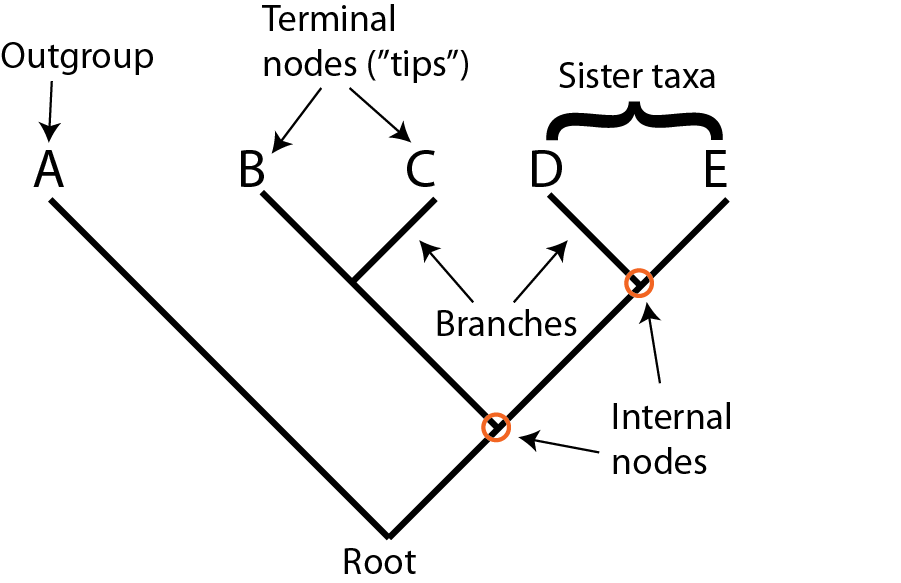

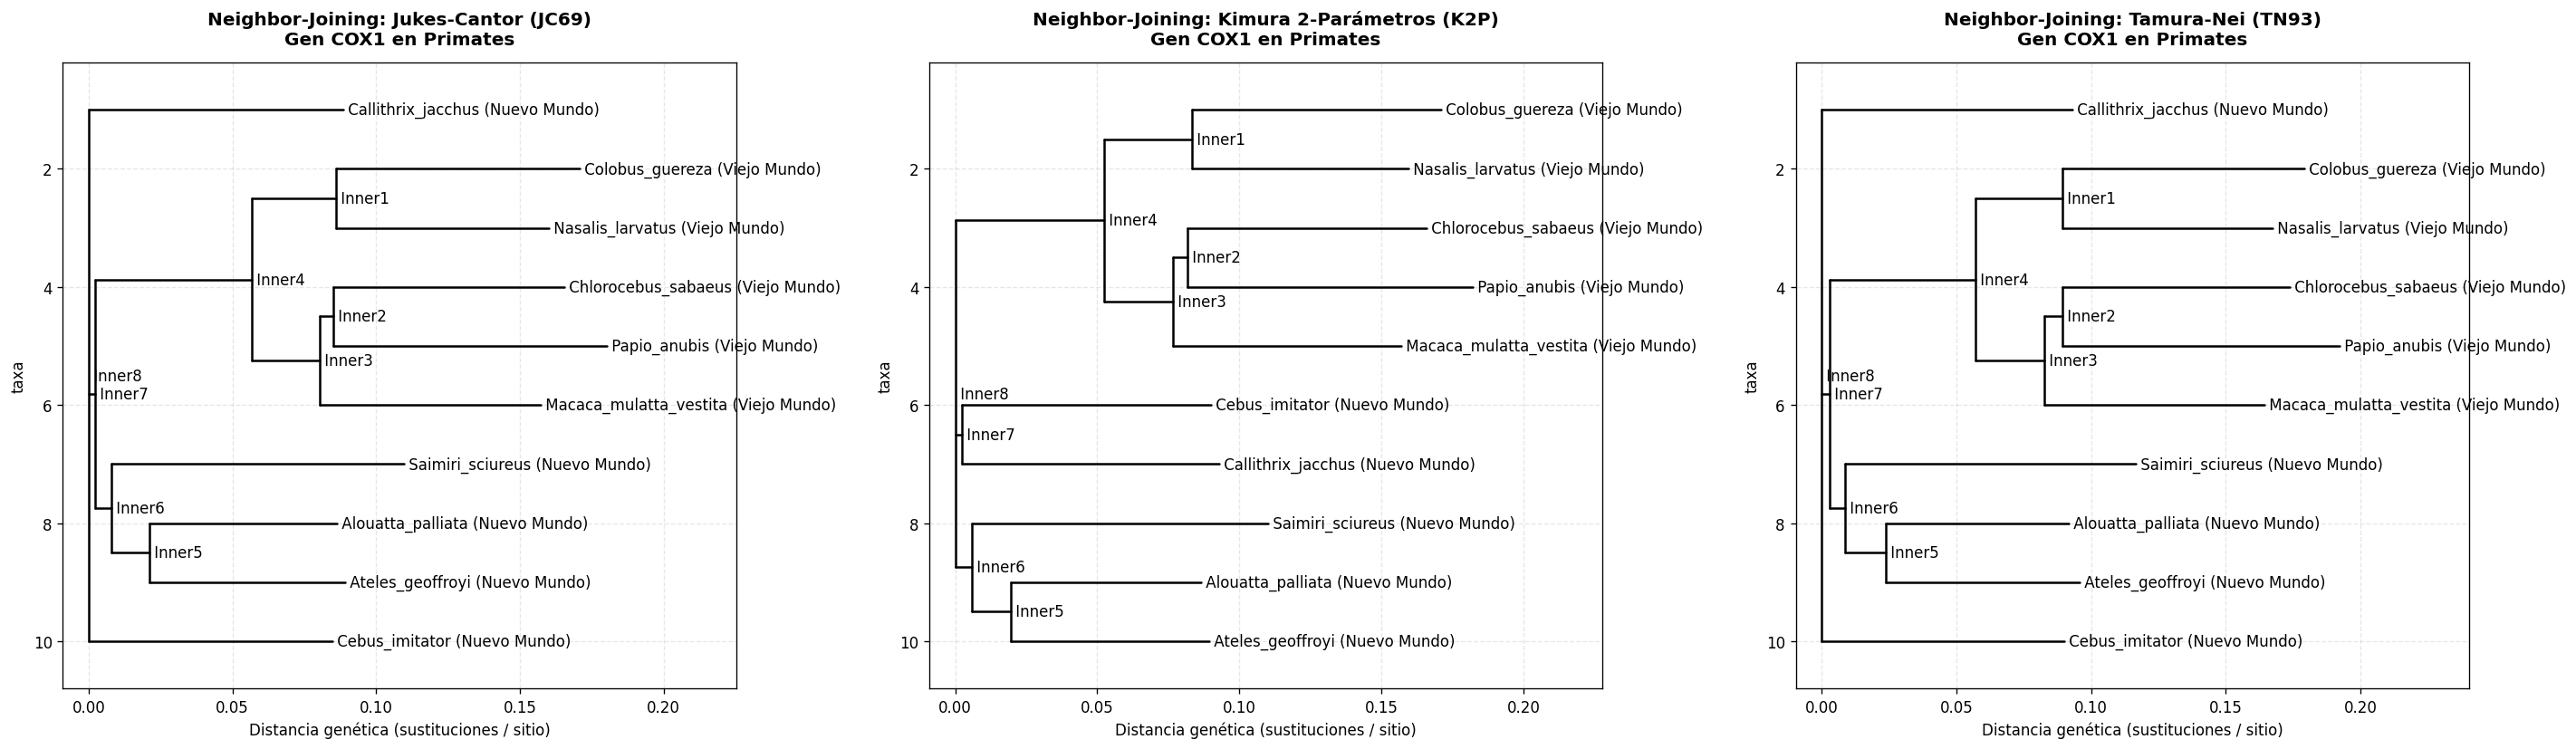

In [4]:
import matplotlib.pyplot as plt
from Bio import Phylo

# Configurar 3 paneles horizontales (1 fila x 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(24, 7), dpi=120)

# 1. Panel JC69
Phylo.draw(arbol_nj_jc69, axes=axes[0], do_show=False)
axes[0].set_title("Neighbor-Joining: Jukes-Cantor (JC69)\nGen COX1 en Primates", fontsize=12, fontweight="bold", pad=12)
axes[0].set_xlabel("Distancia genética (sustituciones / sitio)", fontsize=10)
axes[0].grid(True, linestyle="--", alpha=0.3)

# 2. Panel K2P
Phylo.draw(arbol_nj_k2p, axes=axes[1], do_show=False)
axes[1].set_title("Neighbor-Joining: Kimura 2-Parámetros (K2P)\nGen COX1 en Primates", fontsize=12, fontweight="bold", pad=12)
axes[1].set_xlabel("Distancia genética (sustituciones / sitio)", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.3)

# 3. Panel TN93
Phylo.draw(arbol_nj_tn93, axes=axes[2], do_show=False)
axes[2].set_title("Neighbor-Joining: Tamura-Nei (TN93)\nGen COX1 en Primates", fontsize=12, fontweight="bold", pad=12)
axes[2].set_xlabel("Distancia genética (sustituciones / sitio)", fontsize=10)
axes[2].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


# 5. Análisis comparativo: ¿Qué distancia es mejor y por qué?

### 📊 Tabla Comparativa de Modelos de Distancia

| Modelo | Supuestos Biológicos | Parámetros Considerados | Fortalezas (Pros) | Debilidades (Contras) | ¿Cuándo se recomienda? |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Jukes-Cantor (JC69)** | • Todas las bases tienen igual frecuencia ($25\%$ cada una).<br>• Todas las sustituciones ocurren a la misma velocidad. | 1 parámetro ($p$: diferencias totales). | • El más simple y fácil de calcular.<br>• Requiere muy pocos datos para estimarse. | • Muy poco realista biológicamente.<br>• Subestima distancias en linajes antiguos o con sesgos de mutación. | En secuencias muy parecidas ($p < 0.05$) o como modelo nulo básico. |
| **Kimura 2-Parámetros (K2P / K80)** | • Frecuencias de bases iguales ($25\%$).<br>• Tasa de **transiciones ($P$)** diferente a la de **transversiones ($Q$)**. | 2 parámetros ($P$ transiciones, $Q$ transversiones). | • Corrige el sesgo más común en el ADN: las transiciones son mucho más frecuentes que las transversiones.<br>• Estándar global en código de barras animal (gen COX1). | • Sigue asumiendo que $A, C, G, T$ tienen exactamente la misma frecuencia. | Estándar en bases de datos de Barcoding (BOLD Systems). |
| **Tamura-Nei (TN93)** | • Frecuencias de nucleótidos empíricas desiguales ($g_A \neq g_C \neq g_G \neq g_T$).<br>• Tasas diferentes para transiciones de purinas ($A \leftrightarrow G$), transiciones de pirimidinas ($C \leftrightarrow T$) y transversiones. | Frecuencias de bases + 3 tasas de sustitución. | • El modelo más biológicamente realista para genes mitocondriales.<br>• Corrige el sesgo de composición $A+T$ y la asimetría de transiciones. | • Requiere fórmulas matemáticas más elaboradas. | **El mejor modelo para genomas mitocondriales (COX1)**. |

---

### 🏆 ¿Cuál modelo es el mejor para nuestro taller y por qué?

Para el análisis del gen **COX1 (Citocromo c Oxidasa I)** en primates, el mejor modelo es **Kimura 2-Parámetros (K2P)**, seguido muy de cerca por **Tamura-Nei (TN93)**:

1. **¿Por qué Tamura-Nei (TN93) es superior?**
   * **Sesgo de composición nucleotídica:** En el ADN mitocondrial de mamíferos, las cuatro bases nitrogenadas no se encuentran en un $25\%$ cada una; existe un marcado sesgo donde la suma de Adenina y Timina ($A+T$) suele superar el $55-60\%$. JC69 y K2P ignoran este hecho, mientras que TN93 lo modela explícitamente.
   * **Asimetría de transiciones:** En la mitocondria, las transiciones entre pirimidinas ($C \leftrightarrow T$) ocurren a una tasa diferente y más rápida que las transiciones entre purinas ($A \leftrightarrow G$). TN93 separa ambas tasas ($P_1$ y $P_2$), logrando longitudes de rama más exactas que representan mejor el tiempo evolutivo de divergencia entre los monos del **Nuevo Mundo (Platirrinos)** y del **Viejo Mundo (Catarrinos)**.

2. **¿Por qué Jukes-Cantor (JC69) es el más limitado?**
   * Al asumir que todas las mutaciones son equiprobables y que las 4 bases tienen igual abundancia, **subestima las distancias genéticas** entre especies lejanas (como entre un platirrino y un catarrino), ya que no compensa adecuadamente las sustituciones múltiples recurrentes ("saturación mutacional").

3. **Consistencia Topológica del Neighbor-Joining:**
   * A pesar de las diferencias en la longitud de las ramas, los tres modelos con Neighbor-Joining recuperan la **monofilia perfecta de ambos grupos biogeográficos**:
     * **Clado Viejo Mundo:** *Colobus* y *Nasalis* (subfamilia *Colobinae*) se separan coherentemente de *Macaca*, *Papio* y *Chlorocebus* (subfamilia *Cercopithecinae*).
     * **Clado Nuevo Mundo:** *Alouatta* y *Ateles* (familia *Atelidae*) se agrupan juntos como especies hermanas, diferenciadas de *Cebus*, *Saimiri* y *Callithrix*.

---
Elaborado por: Juan Sebastián Malagón, Eliana Zuluaga Aponte